In [1]:
import numpy as np
import pandas as pd
import subprocess
import os
import sys
import argparse
import glob
import time
from astropy.io import fits as pyfits
import matplotlib.pyplot as plt
from urllib.request import urlopen
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from astropy.time import Time
from contextlib import closing
from astropy import units as u

This file includes the plots created when exploring the different classes of supernovae in our dataset. 
Notes:
- This code was originally sourced in *'raw_stacking.ipynb'* and moved here
- No stacking here (for stacking, see *'stacking.ipynb'*)

Useful Functions

In [2]:
def weighted_stack(df):
    """
    Given a dataframe that has a column named 'File Path' and 'RMS', stacks all of the npy arrays saved
    under the filepaths, weighted by the RMS
    """
    weighted_sum = None
    total_weight = 0


    rms_list = []
    for _, row in df.iterrows():
        file_path = row['File Path']
        rms = row['RMS']

        # Ensure file exists and RMS is valid
        if not isinstance(file_path, str) or not os.path.exists(file_path) or rms is None or rms <= 0 or np.isnan(rms):
            continue

        # Load the array and check its shape
        array = np.load(file_path)

        # Compute weight and accumulate
        weight = 1 / (rms ** 2)
        weighted_sum = array * weight if weighted_sum is None else weighted_sum + array * weight
        total_weight += weight
        rms_list.append(rms)

    print(rms_list)

    # Normalize to get the final stacked array
    return None if total_weight == 0 else weighted_sum / total_weight

In [3]:
def process_array_for_rms(npy_array):

    try:
        # Load the NumPy array
        im = npy_array

        # 3-sigma clipping (find the root mean square of values that are not above 3 standard deviations)
        rms_temp = np.ma.std(im)
        keep = np.ma.abs(im) <= 3 * rms_temp
        rms = np.ma.std(im[keep])

        return rms

    except Exception as e:
        print(f"An error occurred while processing the array: {e}")
        return None

In [4]:
def calculate_luminosity(flux, redshift):
    """
    Calculate luminosity from flux and redshift.

    Parameters:
    - flux (float or np.ndarray): Flux in Janskys.
    - redshift.

    Returns:
    - np.ndarray: Luminosity in erg/s/Hz.
    """
    # Constants

    c = 3e5  # Speed of light in km/s
    H0 = 70  # Hubble constant in km/s/Mpc
    MPC_TO_CM = 3.0857e24  # 1 Mpc to cm
    JY_TO_ERG = 1e-23  # Jansky to erg/s/cm²/Hz
    FOUR_PI = 4 * np.pi

    # Calculate Approximate Distance
    dist_mpc = (c * redshift) / H0

    # Convert flux to erg/s/cm²/Hz
    flux_erg = flux * JY_TO_ERG

    # Convert distance to cm
    distance_cm = dist_mpc * MPC_TO_CM

    # Calculate luminosity
    luminosity = FOUR_PI * (distance_cm ** 2) * flux_erg
    return luminosity


### Reading in Data and Checking Counts

In [6]:
# Read in the full dataset
full_df = pd.read_csv('final_full_data_centered.csv')


In [8]:
type_counts = full_df['type'].value_counts().reset_index()
type_counts.columns = ['Type', 'Count']
type_counts

,Type,Count
0,SN Ia,19704
1,SN II,4208
2,SN IIn,761
3,SN Ia-91T,687
4,SN Ic,538
5,SN Ib,485
6,SN IIb,396
7,SN IIP,366
8,SLSN-I,235
9,SN Ic-BL,219


In [9]:
detections_ids = [
    "ZTF18acbwopo",
    "ZTF19aakkths",
    "ZTF19abpidqn",
    "ZTF19abxqppy",
    "ZTF19acxxwvi",
    "ZTF19adcfsad",
    "ZTF20aaieyup",
    "ZTF20acytgxf",
    "ZTF20abegirf",
    "ZTF20acnvniw",
    "ZTF21acpoujw",
    "ZTF21aagtpro",
    "ZTF21ablwehd",
    "ZTF22aaagrce",
    "ZTF23aabngtm",
    "ZTF23abbccir",
    "ZTF24aahgqwk",
    "ZTF17aaazdba",
    "ZTF18acpdvos",
    "ZTF19abucwzt",
    "ZTF19abzrhgq"
]


In [10]:
# Filtering for IDs not in list above
filtered_full_df = full_df[~full_df["Name"].isin(detections_ids)]

### Create Individual Dataframes for Each Type

#### Unfiltered Dataframes (includes known in literature)

In [11]:
# Ia is just those with Ia in it (no Ia-CSM)
ia_df = full_df[
    full_df['type'].str.contains('SN Ia', na=False) &
    ~full_df['type'].str.contains('SN Ia-CSM', na=False)
]

# Ia-CSM
ia_csm_df = full_df[full_df['type'] == 'SN Ia-CSM']

# IIn just includes IIn
iin_df = full_df[full_df['type'].str.contains('SN IIn', na=False)]

# Grouped together stripped envelope types
stripped_envelope_types = ['SN IIb', 'SN Ib', 'SN Ic', 'SN Ib/c', 'SN Ic-BL']
strip_envelope_df = full_df[full_df['type'].isin(stripped_envelope_types)]

# Type II and IIP grouped together
ii_types = ['SN II', 'SN IIP']
ii_df = full_df[full_df['type'].isin(ii_types)]

# TDEs have their own category
tde_df = full_df[full_df['type'].str.contains('TDE', na=False)]

# Ibn and Icn grouped together
ibn_icn_types =  ['SN Icn', 'SN Ibn']
ibn_icn_df = full_df[full_df['type'].isin(ibn_icn_types)]

# SLSN1 have their own category
slsn_1_df= full_df[full_df['type'] == 'SLSN-I']

# SLSN2 have their own category
slsn_2_df= full_df[full_df['type'] == 'SLSN-II']

#### Filtered (only objects not known in literature)

In [17]:
# Repeat the categorization but with the known literature objects filtered out

filtered_ia_df = filtered_full_df[filtered_full_df['type'].str.contains('SN Ia', na=False)]

filtered_iin_df = filtered_full_df[filtered_full_df['type'].str.contains('SN IIn', na=False)]

stripped_envelope_types = ['SN IIb', 'SN Ib', 'SN Ic', 'SN Ib/c', 'SN Ic-BL']
filtered_strip_envelope_df = filtered_full_df[filtered_full_df['type'].isin(stripped_envelope_types)]

ii_types = ['SN II', 'SN IIP']
filtered_ii_df = filtered_full_df[filtered_full_df['type'].isin(ii_types)]

filtered_tde_df = filtered_full_df[filtered_full_df['type'].str.contains('TDE', na=False)]

ibn_icn_types = ['SN Icn', 'SN Ibn']
filtered_ibn_icn_df = filtered_full_df[filtered_full_df['type'].isin(ibn_icn_types)]

filtered_slsn_1_df = filtered_full_df[filtered_full_df['type'] == 'SLSN-I']
filtered_slsn_2_df = filtered_full_df[filtered_full_df['type'] == 'SLSN-II']

In [12]:
# Code to create a summary dataframe that shows how many obs, how many individual objects, and the types included in the categories

dfs = {
    "ia_df": ia_df,
    "ia_csm_df": ia_csm_df,
    "iin_df": iin_df,
    "strip_envelope_df": strip_envelope_df,
    "ii_df": ii_df,
    "tde_df": tde_df,
    "ibn_icn_df": ibn_icn_df,
    "slsn_1_df": slsn_1_df,
    "slsn_2_df": slsn_2_df,
}

# Collect summary info
summary = []
for name, df in dfs.items():
    total_len = len(df)
    unique_names = df['Name'].nunique() if 'Name' in df.columns else None
    unique_types = df['type'].unique().tolist() if 'type' in df.columns else None
    summary.append({
        "DataFrame": name,
        "Total Rows": total_len,
        "Unique Names": unique_names,
        "Types Included": unique_types
    })

summary_df = pd.DataFrame(summary)

summary_df.sort_values(by = "Total Rows", ascending = False)

,DataFrame,Total Rows,Unique Names,Types Included
0,ia_df,20816,6959,"[SN Ia, SN Ia-pec, SN Ia-91T, SN Ia-91bg, SN I..."
4,ii_df,4574,1530,"[SN II, SN IIP]"
3,strip_envelope_df,1746,583,"[SN Ic, SN Ib, SN IIb, SN Ib/c, SN Ic-BL]"
2,iin_df,764,255,"[SN IIn, SN IIn-pec]"
7,slsn_1_df,235,79,[SLSN-I]
5,tde_df,174,58,[TDE]
8,slsn_2_df,138,46,[SLSN-II]
6,ibn_icn_df,120,40,"[SN Ibn, SN Icn]"
1,ia_csm_df,56,19,[SN Ia-CSM]


In [19]:
filtered_dfs = {
    "ia_df": filtered_ia_df,
    "iin_df": filtered_iin_df,
    "strip_envelope_df": filtered_strip_envelope_df,
    "ii_df": filtered_ii_df,
    "tde_df": filtered_tde_df,
    "ibn_icn_df": filtered_ibn_icn_df,
    "slsn_1_df": filtered_slsn_1_df,
    "slsn_2_df": filtered_slsn_2_df,
}

# Collect summary info
summary = []
for name, df in filtered_dfs.items():
    total_len = len(df)
    unique_names = df['Name'].nunique() if 'Name' in df.columns else None
    unique_types = df['type'].unique().tolist() if 'type' in df.columns else None
    summary.append({
        "DataFrame": name,
        "Total Rows": total_len,
        "Unique Names": unique_names,
        "Types Included": unique_types
    })

filtered_summary_df = pd.DataFrame(summary)

filtered_summary_df.sort_values(by = "Total Rows", ascending = False)

,DataFrame,Total Rows,Unique Names,Types Included
0,ia_df,20872,6978,"[SN Ia, SN Ia-pec, SN Ia-91T, SN Ia-91bg, SN I..."
3,ii_df,4550,1522,"[SN II, SN IIP]"
2,strip_envelope_df,1725,576,"[SN Ic, SN Ib, SN IIb, SN Ib/c, SN Ic-BL]"
1,iin_df,755,252,"[SN IIn, SN IIn-pec]"
6,slsn_1_df,235,79,[SLSN-I]
4,tde_df,165,55,[TDE]
7,slsn_2_df,138,46,[SLSN-II]
5,ibn_icn_df,120,40,"[SN Ibn, SN Icn]"


### Exploratory Plotting

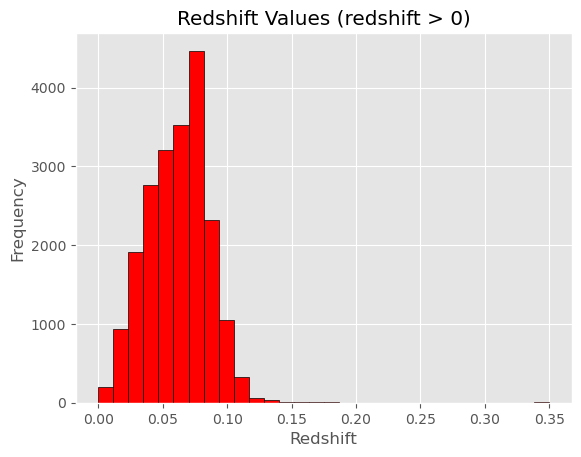

In [41]:
plt.style.use('ggplot')

plt.hist(ia_df['redshift'], bins=30, edgecolor='black', color = "red")

# Labels and title
plt.xlabel('Redshift')
plt.ylabel('Frequency')
plt.title('Redshift Values (redshift > 0)')

# Show the plot
plt.show()

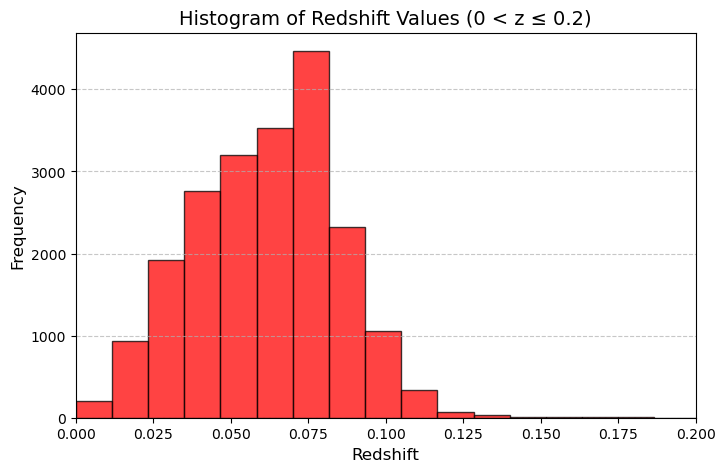

In [11]:

# Create the histogram
plt.figure(figsize=(8, 5))
plt.hist(ia_df['redshift'], bins=30, edgecolor='black', color='#FF0404', alpha=0.75)

# Labels and title
plt.xlabel('Redshift', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Redshift Values (0 < z ≤ 0.2)', fontsize=14)

# Limit x-axis range to 0 to 0.2
plt.xlim(0, 0.2)

# Improve grid visibility
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def plot_redshift_histogram(
    df,
    column='redshift',
    xlim=(0, 0.2),
    bin_width=0.01,
    title=None,
    color='#FF0404'
):
    plt.style.use('ggplot')

    # Create evenly spaced bins
    bins = np.arange(xlim[0], xlim[1] + bin_width, bin_width)

    # Create the histogram
    plt.hist(df[column], bins=bins, edgecolor='black', color=color, alpha=0.75)

    # Labels and title with serif font
    plt.xlabel('Redshift', fontsize=12, fontname='serif')
    plt.ylabel('Frequency', fontsize=12, fontname='serif')
    if title:
        plt.title(title, fontsize=14, fontname='serif')
    else:
        plt.title(f'Histogram of {column} Values', fontsize=14, fontname='serif')

    # Set x-axis limits
    plt.xlim(*xlim)

    # Improve grid visibility
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Show the plot
    plt.show()


In [14]:
from matplotlib import cm
def plot_binned_histogram(
    df,
    column,
    bin_ranges,
    bin_width=100,
    cmap_name='viridis',
    use_color=True,
    title=None  # Add this line
):
    # Filter out NaNs and keep only values ≥ 0
    values = df[column].dropna()
    values = values[values >= 0]

    # Create bin edges based on bin width
    bin_edges = np.arange(0, max(values) + bin_width, bin_width)

    # Create color palette from colormap
    color_palette = cm.get_cmap(cmap_name, len(bin_ranges))

    # Plot histogram
    counts, bins, patches = plt.hist(values, bins=bin_edges, edgecolor='black', alpha=0.85)

    if use_color:
        # Apply color based on bin_ranges
        for i, patch in enumerate(patches):
            bin_start = bins[i]
            bin_end = bins[i + 1]

            for j, (start, end) in enumerate(bin_ranges):
                if bin_start >= start and bin_end <= end:
                    patch.set_facecolor(color_palette(j))
                    break
    else:
        for patch in patches:
            patch.set_facecolor('crimson')

    # Labels and formatting
    plt.xlabel(column, fontsize=12, fontname='serif')
    plt.ylabel('Frequency', fontsize=12, fontname='serif')
    if title:
        plt.title(title, fontsize=14, fontname='serif')  # Use the provided title
    else:
        plt.title(f'{column} Binned Histogram', fontsize=14, fontname='serif')  # Fallback title
    plt.xlim(left=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


C:\Users\kerbe\AppData\Local\Temp\ipykernel_31888\1306187716.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_palette = cm.get_cmap(cmap_name, len(bin_ranges))


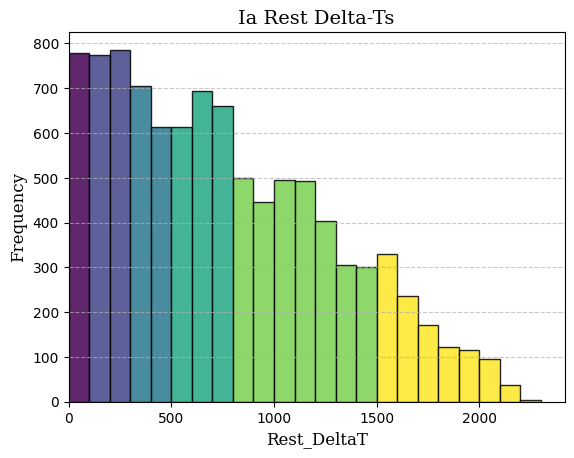

In [15]:
plot_binned_histogram(ia_df, 'Rest_DeltaT', [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 2500)], title = 'Ia Rest Delta-Ts')

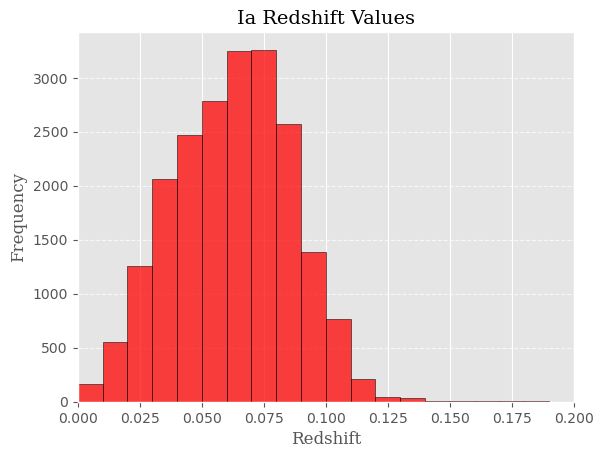

In [46]:
plot_redshift_histogram(ia_df, title = 'Ia Redshift Values')

C:\Users\kerbe\AppData\Local\Temp\ipykernel_31888\1306187716.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_palette = cm.get_cmap(cmap_name, len(bin_ranges))


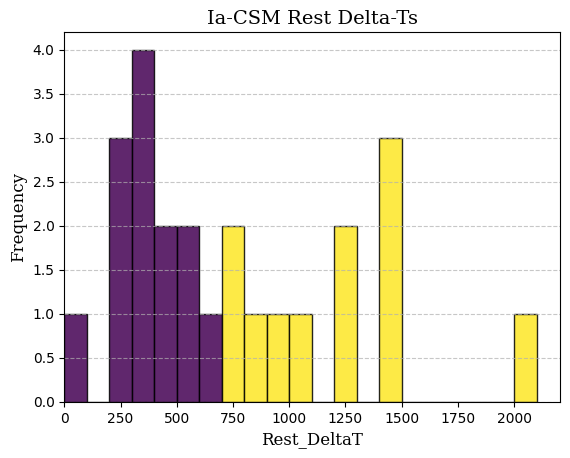

In [23]:
plot_binned_histogram(ia_csm_df, 'Rest_DeltaT', [(0, 700), (500, 2500)], title = 'Ia-CSM Rest Delta-Ts')

C:\Users\Jack Pope\AppData\Local\Temp\ipykernel_6780\1306187716.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_palette = cm.get_cmap(cmap_name, len(bin_ranges))


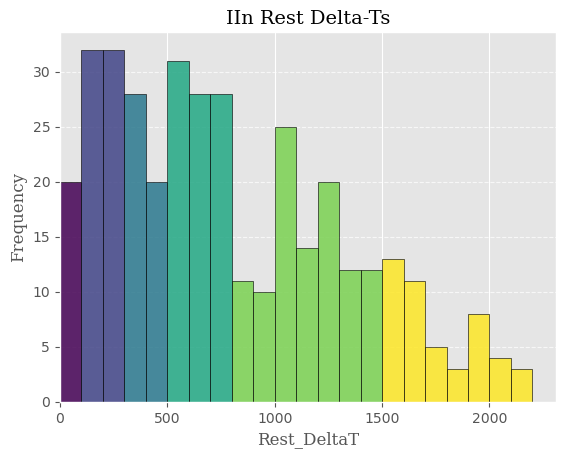

In [47]:
plot_binned_histogram(iin_df, 'Rest_DeltaT', [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 2500)], title = 'IIn Rest Delta-Ts')

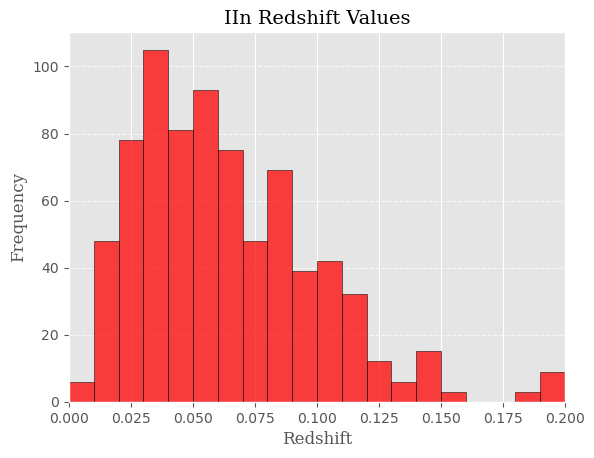

In [48]:
plot_redshift_histogram(iin_df, title = 'IIn Redshift Values')

C:\Users\Jack Pope\AppData\Local\Temp\ipykernel_6780\1306187716.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_palette = cm.get_cmap(cmap_name, len(bin_ranges))


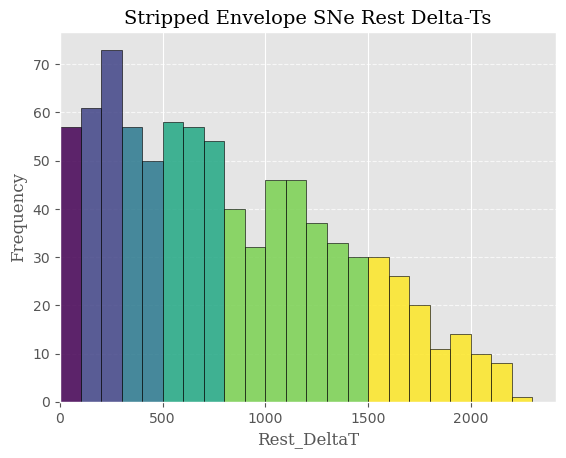

In [49]:
plot_binned_histogram(strip_envelope_df, 'Rest_DeltaT', [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 2500)],
                      title = 'Stripped Envelope SNe Rest Delta-Ts')


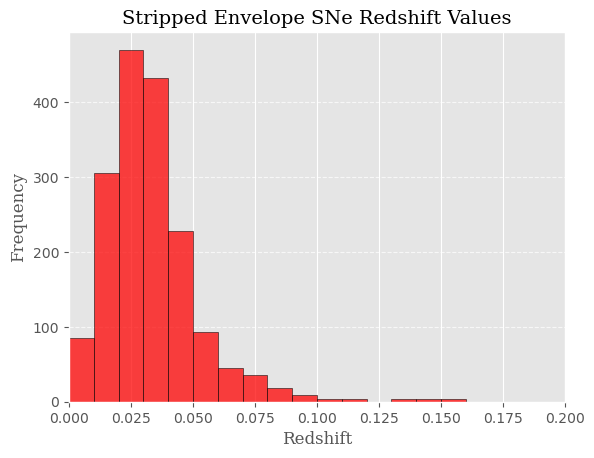

In [50]:
plot_redshift_histogram(strip_envelope_df, title = 'Stripped Envelope SNe Redshift Values')

C:\Users\Jack Pope\AppData\Local\Temp\ipykernel_6780\1306187716.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_palette = cm.get_cmap(cmap_name, len(bin_ranges))


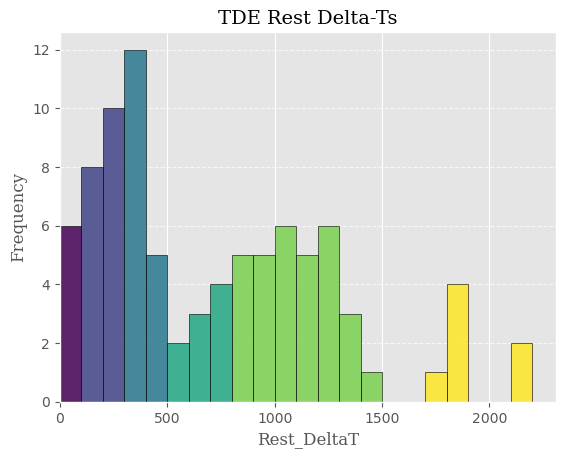

In [51]:
plot_binned_histogram(tde_df, 'Rest_DeltaT', [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 2500)],
                      title = 'TDE Rest Delta-Ts')

C:\Users\Jack Pope\AppData\Local\Temp\ipykernel_6780\1306187716.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_palette = cm.get_cmap(cmap_name, len(bin_ranges))


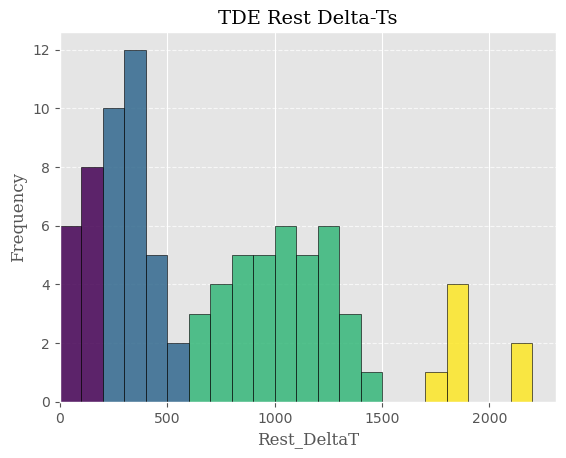

In [52]:
plot_binned_histogram(tde_df, 'Rest_DeltaT', [(0, 200), (200, 600), (600, 1500), (1500, 2600)],
                      title = 'TDE Rest Delta-Ts')

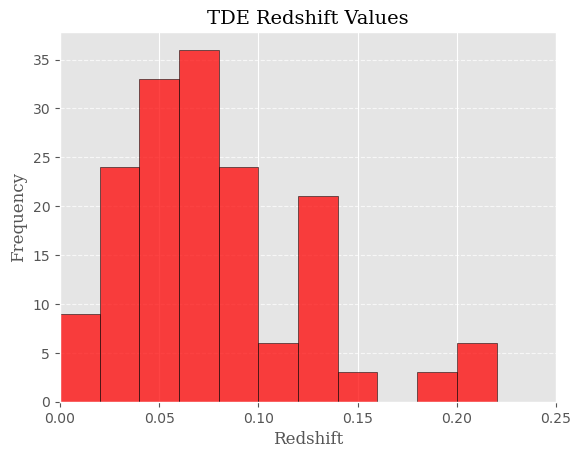

In [53]:
plot_redshift_histogram(tde_df, title = 'TDE Redshift Values', xlim = (0, 0.25), bin_width = 0.02)

C:\Users\Jack Pope\AppData\Local\Temp\ipykernel_6780\1306187716.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_palette = cm.get_cmap(cmap_name, len(bin_ranges))


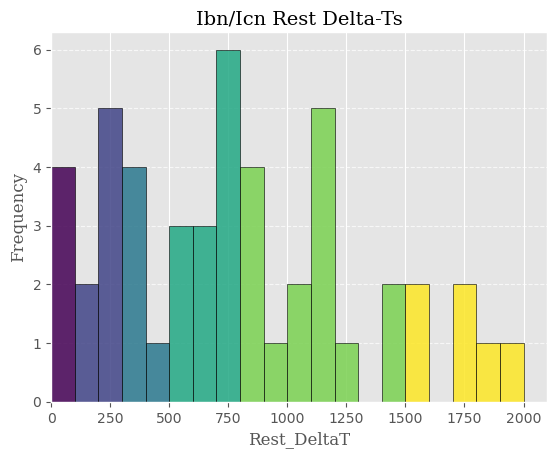

In [54]:
plot_binned_histogram(ibn_icn_df, 'Rest_DeltaT', [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 2500)],
                      title = 'Ibn/Icn Rest Delta-Ts')

C:\Users\Jack Pope\AppData\Local\Temp\ipykernel_6780\1306187716.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_palette = cm.get_cmap(cmap_name, len(bin_ranges))


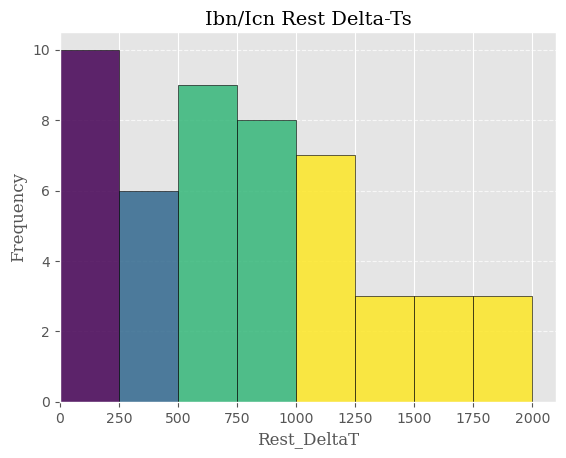

In [55]:
plot_binned_histogram(ibn_icn_df, 'Rest_DeltaT', [(0, 250), (250, 500), (500, 1000), (1000, 2500)], bin_width= 250,
                      title = 'Ibn/Icn Rest Delta-Ts')

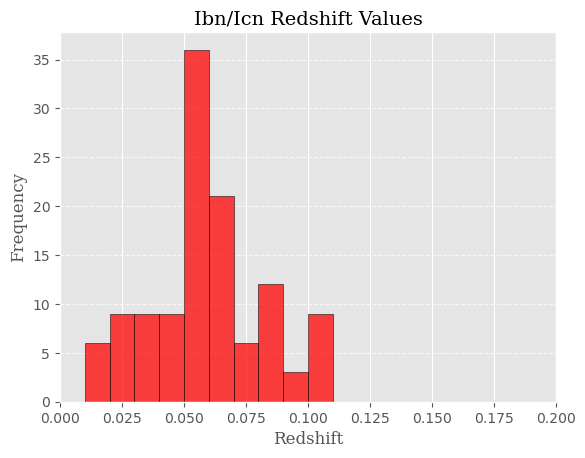

In [56]:
plot_redshift_histogram(ibn_icn_df, title = 'Ibn/Icn Redshift Values')

C:\Users\Jack Pope\AppData\Local\Temp\ipykernel_6780\1306187716.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_palette = cm.get_cmap(cmap_name, len(bin_ranges))


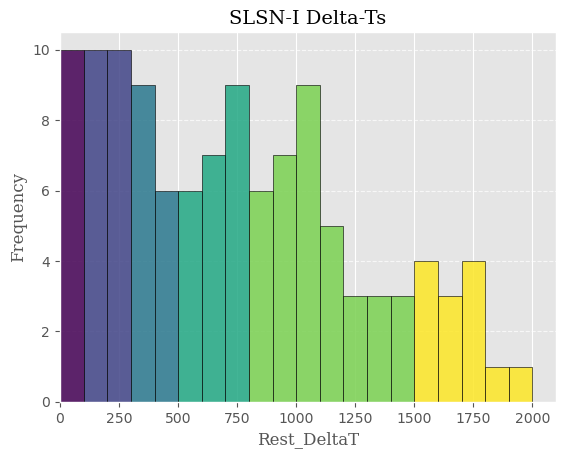

In [57]:
plot_binned_histogram(slsn_1_df, 'Rest_DeltaT', [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 2500)],
                      title = 'SLSN-I Delta-Ts')

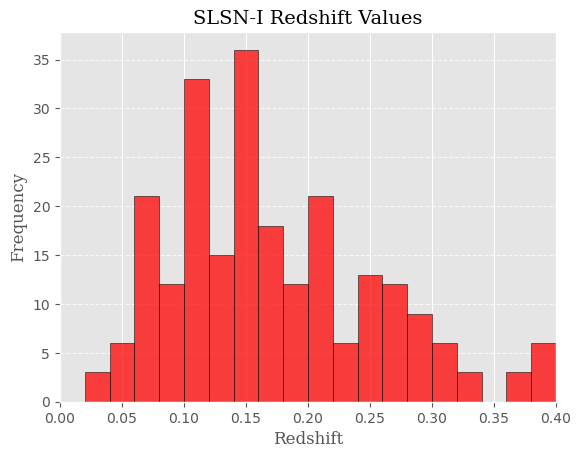

In [58]:
plot_redshift_histogram(slsn_1_df, title = 'SLSN-I Redshift Values', xlim = (0, 0.4), bin_width = 0.02)

C:\Users\Jack Pope\AppData\Local\Temp\ipykernel_6780\1306187716.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_palette = cm.get_cmap(cmap_name, len(bin_ranges))


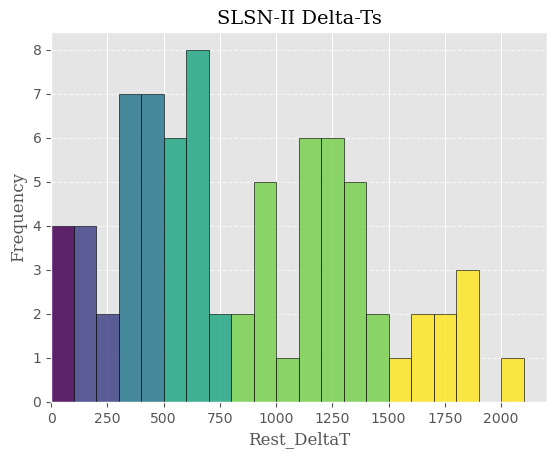

In [59]:
plot_binned_histogram(slsn_2_df, 'Rest_DeltaT', [(0, 100), (100, 300), (300, 500), (500, 800), (800, 1500), (1500, 2500)],
                      title = 'SLSN-II Delta-Ts')

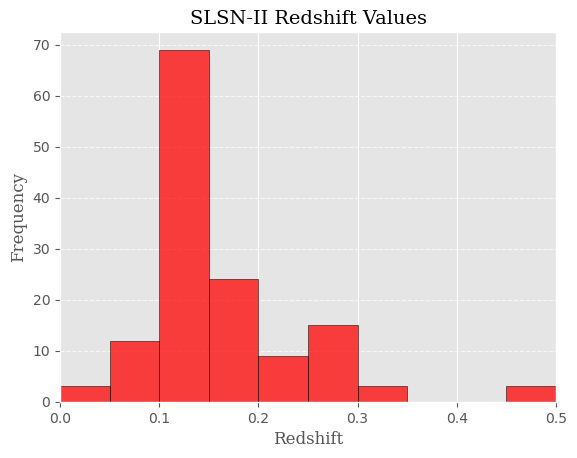

In [60]:
plot_redshift_histogram(slsn_2_df, title = 'SLSN-II Redshift Values', xlim = (0, 0.5), bin_width = 0.05)

list_dfs = [ia_df, iin_df, strip_envelope_df, tde_df, ibn_icn_df, slsn_1_df, slsn_2_df]

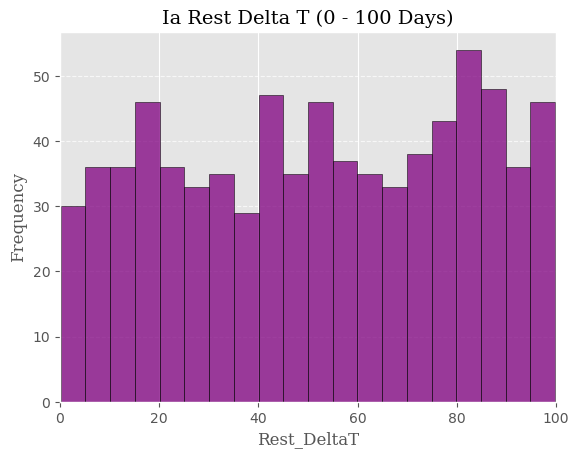

In [61]:

plt.style.use('ggplot')
# Filter Rest_DeltaT to include only values greater than or equal to 0 and less than 100
filtered_rest_delta_t = ia_df['Rest_DeltaT'].dropna()
filtered_rest_delta_t = filtered_rest_delta_t[(filtered_rest_delta_t >= 0) & (filtered_rest_delta_t <= 100)]

# Create the histogram with one color
plt.hist(filtered_rest_delta_t, bins=20, color='purple', edgecolor='black', alpha=0.75)

# Labels and title
plt.xlabel('Rest_DeltaT', fontsize=12, fontname = 'serif')
plt.ylabel('Frequency', fontsize=12, fontname = 'serif')
plt.title('Ia Rest Delta T (0 - 100 Days)', fontsize=14, fontname = 'serif')

# Set the x-axis to start at 0 and end at 100
plt.xlim(0, 100)

# Improve grid visibility
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()


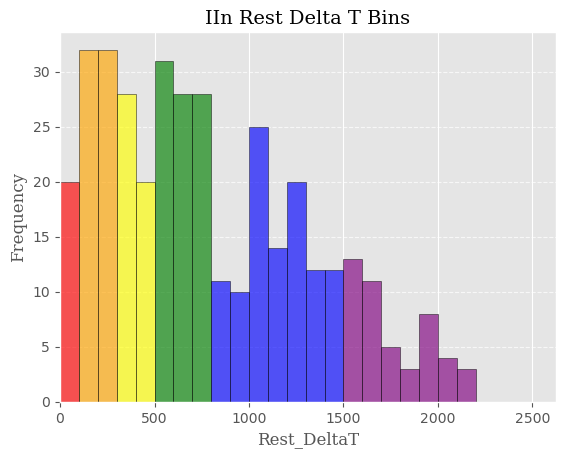

In [62]:
plt.style.use('ggplot')
# Filter Rest_DeltaT to include only values greater than or equal to 0
filtered_rest_delta_t = iin_df['Rest_DeltaT'].dropna()
filtered_rest_delta_t = filtered_rest_delta_t[filtered_rest_delta_t >= 0]

# Define the bin edges based on 100-wide bins
bin_edges = np.arange(0, 2501, 100)  # Now extends to 1600 to cover > 1500

# Create the histogram with the custom bin edges
counts, bins, patches = plt.hist(filtered_rest_delta_t, bins=bin_edges, edgecolor='black', alpha=0.65)

# Set colors with transparency for each bin based on the ranges
colors = ['red', 'orange', 'yellow', 'green', 'blue', 'purple']  # Adding purple for > 1500

# Apply the colors to the corresponding bins
for i, patch in enumerate(patches):
    # Determine which color the current bin belongs to
    if bins[i] < 100:
        patch.set_facecolor('red')
    elif bins[i] < 300:
        patch.set_facecolor('orange')
    elif bins[i] < 500:
        patch.set_facecolor('yellow')
    elif bins[i] < 800:
        patch.set_facecolor('green')
    elif bins[i] < 1500:
        patch.set_facecolor('blue')
    else:
        patch.set_facecolor('purple')  # For the last bin (values > 1500)

# Labels and title
plt.xlabel('Rest_DeltaT', fontsize=12, fontname = 'serif')
plt.ylabel('Frequency', fontsize=12, fontname = 'serif')
plt.title('IIn Rest Delta T Bins', fontsize=14, fontname='serif')
# Set the x-axis to start at 0
plt.xlim(left=0)

# Improve grid visibility
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

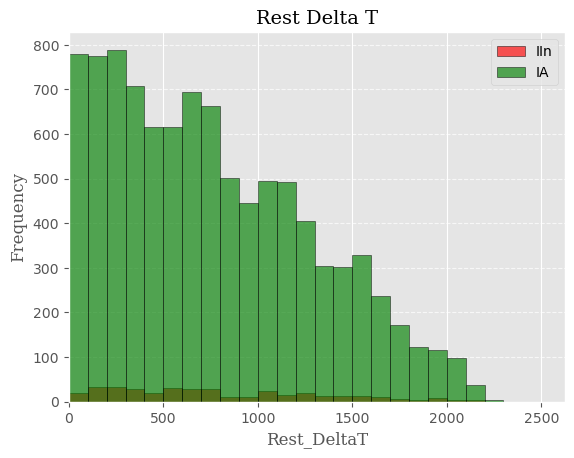

In [63]:
plt.style.use('ggplot')

# Filter Rest_DeltaT to include only values greater than or equal to 0
filtered_iin_rest_delta_t = iin_df['Rest_DeltaT'].dropna()
filtered_iin_rest_delta_t = filtered_iin_rest_delta_t[filtered_iin_rest_delta_t >= 0]

# Do the same for ia_df
filtered_ia_rest_delta_t = ia_df['Rest_DeltaT'].dropna()
filtered_ia_rest_delta_t = filtered_ia_rest_delta_t[filtered_ia_rest_delta_t >= 0]

# Define the bin edges based on 100-wide bins
bin_edges = np.arange(0, 2501, 100)

# Create the histogram for IIn (with red color)
counts_iin, bins_iin, patches_iin = plt.hist(filtered_iin_rest_delta_t, bins=bin_edges, edgecolor='black', alpha=0.65, color='red', label='IIn')

# Create the histogram for IA (with green color, for example)
counts_ia, bins_ia, patches_ia = plt.hist(filtered_ia_rest_delta_t, bins=bin_edges, edgecolor='black', alpha=0.65, color='green', label='IA')

# Set labels and title
plt.xlabel('Rest_DeltaT', fontsize=12, fontname='serif')
plt.ylabel('Frequency', fontsize=12, fontname='serif')
plt.title('Rest Delta T', fontsize=14, fontname='serif')

# Set the x-axis to start at 0
plt.xlim(left=0)

# Improve grid visibility
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add a legend to differentiate the two histograms
plt.legend()

# Show the plot
plt.show()
